# Space Debris Collision Prediction — Model Training Notebook

**Pipeline stage:** Dataset → Preprocessing → EDA → Feature Engineering → **CNN / RNN / LSTM → Model Comparison → Best Model Selection** → SHAP → Decision Engine

This notebook trains and compares the three candidate architectures on this
project's own real data (`data/engineered_data.csv` — ESA conjunction-event
features, no synthetic data), auto-selects the best model by combined
F1-score + ROC-AUC, and saves all deployment artifacts.

It reuses the exact model-building functions from `src/scripts/train_models.py`
(imported, not re-defined) so the notebook and the production training script
can never drift out of sync — this notebook is a reproducible, inspectable
walkthrough of the same pipeline `train_models.py` runs end-to-end.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "src").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import train_models as tm

print("Project root:", PROJECT_ROOT)
print("Data file:", tm.DATA_PATH, "exists:", tm.DATA_PATH.exists())

I0000 00:00:1785756411.762481     584 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785756429.675979     584 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785756439.453439     584 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Project root: /home/claude/upgraded/space_debris_project_upgraded-main
Data file: /home/claude/upgraded/space_debris_project_upgraded-main/data/engineered_data.csv exists: True


## 1. Dataset

Loading the real, already-preprocessed & feature-engineered table produced
by `src/scripts/preprocess.py` and `src/scripts/feature_engineering.py`
(102 engineered features + `risk` (log10 Pc) + `risk_label` (binary target,
`risk > -6`, i.e. Pc > 1e-6 — the ESA Kelvins convention)).

In [2]:
df = pd.read_csv(tm.DATA_PATH)
print("Shape:", df.shape)
print("\nClass balance (risk_label):")
print(df["risk_label"].value_counts())
df.head()

Shape: (5000, 104)

Class balance (risk_label):
risk_label
0    4521
1     479
Name: count, dtype: int64


,time_to_tca,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,...,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP,relative_pos_mag,relative_vel_mag,risk,risk_label
0,-0.885890,-1.533196,-0.059131,-0.112738,0.722585,0.766851,0.400739,-0.856735,-0.049814,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,1.217640,1.270423,-10.204955,0
1,-1.064372,-1.547201,-0.059130,-0.139299,0.722585,0.798674,0.390225,-0.835133,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,1.219674,1.270370,-10.355758,0
2,-1.191191,-1.545689,-0.059130,-0.144135,0.722585,0.799140,0.388533,-0.831168,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,1.216726,1.270370,-10.345631,0
3,-1.376240,-1.544183,-0.059130,-0.136847,0.722585,0.796190,0.391422,-0.837057,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.793151,0.663537,1.219752,1.270370,-10.337809,0
4,-1.536124,-1.551157,-0.059130,-0.141682,0.722585,0.805504,0.389541,-0.833154,-0.048436,-0.738974,...,-0.121892,-0.116755,0.772746,0.301287,0.793151,0.663537,1.222590,1.270370,-10.391260,0


## 2. Preprocessing & Feature Engineering (recap)

Already performed upstream by `src/scripts/preprocess.py` (cleaning, scaling)
and `src/scripts/feature_engineering.py` (derived features such as
`relative_pos_mag`, `mahalanobis_distance`, etc.) — not repeated here to
avoid duplicating that logic. This notebook picks up from the final table.

Below: the train/test split + `StandardScaler` fit, using the exact same
`load_split()` function `train_models.py` calls (imported above), so the
split this notebook evaluates on is identical to the one the production
script uses.

In [3]:
X_train, X_test, y_train, y_test, n_features, feature_cols = tm.load_split()
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("n_features:", n_features)
print("scaler saved to:", tm.MODELS_DIR / "scaler.joblib")

X_train: (4000, 1, 102)  X_test: (1000, 1, 102)
n_features: 102
scaler saved to: /home/claude/upgraded/space_debris_project_upgraded-main/models/scaler.joblib


## 3. Train CNN, RNN, and LSTM

Same architectures/hyperparameters as `train_models.py` (`build_cnn`, `build_rnn`, `build_lstm` — imported, not redefined), with `EarlyStopping` + `ReduceLROnPlateau`.

In [4]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

builders = {"CNN": tm.build_cnn, "RNN": tm.build_rnn, "LSTM": tm.build_lstm}
results = {}
trained = {}
histories = {}

for name, builder in builders.items():
    print(f"\nTraining {name}...")
    model = builder(n_features)
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )
    metrics = tm.evaluate(model, X_test, y_test)
    results[name] = metrics
    trained[name] = model
    histories[name] = history
    print(f"{name}: {metrics}")


Training CNN...


CNN: {'Accuracy': 0.983, 'Precision': 0.9157894736842105, 'Recall': 0.90625, 'F1-Score': 0.9109947643979057, 'ROC-AUC': 0.9948492809734513}

Training RNN...


RNN: {'Accuracy': 0.983, 'Precision': 0.8910891089108911, 'Recall': 0.9375, 'F1-Score': 0.9137055837563451, 'ROC-AUC': 0.9971077617994101}

Training LSTM...


LSTM: {'Accuracy': 0.982, 'Precision': 0.8823529411764706, 'Recall': 0.9375, 'F1-Score': 0.9090909090909091, 'ROC-AUC': 0.993385877581121}


## 4. Model Comparison

In [5]:
comparison = pd.DataFrame(results).T
comparison["Combined_F1_ROCAUC"] = (comparison["F1-Score"] + comparison["ROC-AUC"]) / 2
comparison = comparison.sort_values("Combined_F1_ROCAUC", ascending=False)
comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Combined_F1_ROCAUC
RNN,0.983,0.891089,0.93750,0.913706,0.997108,0.955407
CNN,0.983,0.915789,0.90625,0.910995,0.994849,0.952922
LSTM,0.982,0.882353,0.93750,0.909091,0.993386,0.951238


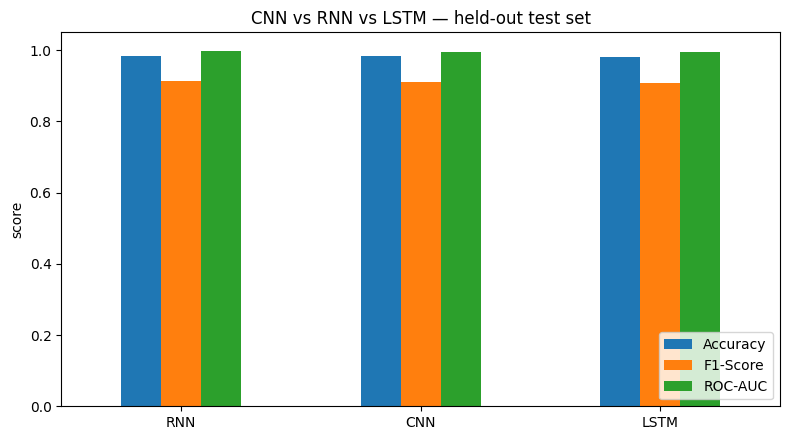

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison[["Accuracy", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_title("CNN vs RNN vs LSTM — held-out test set")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Automatic Best-Model Selection

Selection rule: **argmax over (F1-Score + ROC-AUC) / 2** — not ROC-AUC
alone, so a model that's merely well-ranked but imprecise at the decision
threshold can't win over one that's both accurate *and* well-calibrated.

In [7]:
best_name = comparison["Combined_F1_ROCAUC"].idxmax()
best_model = trained[best_name]

print(f"Best model: {best_name}")
print(comparison.loc[best_name])

Best model: RNN
Accuracy              0.983000
Precision             0.891089
Recall                0.937500
F1-Score              0.913706
ROC-AUC               0.997108
Combined_F1_ROCAUC    0.955407
Name: RNN, dtype: float64


## 6. Save Deployment Artifacts

Saves the winner as `models/best_model.keras` **and** `models/best_model.h5`
(dual format), plus a TensorFlow-free NumPy weight export (there is no real
`.npyth` model format — see `tm.export_numpy_deployment`'s docstring for why
that's not a thing, and what's provided instead), the fitted scaler, and
`outputs/metrics.csv` / `outputs/best_model.json`.

Skip this cell if you only want to *inspect* results without overwriting
the artifacts already produced by running `python src/scripts/train_models.py`
directly.

In [8]:
import json

best_model.save(tm.MODELS_DIR / "best_model.keras")
best_model.save(tm.MODELS_DIR / "best_model.h5")
tm.export_numpy_deployment(best_model, tm.DEPLOY_DIR / best_name.lower(), feature_cols, best_name)

comparison.to_csv(tm.OUTPUTS_DIR / "metrics.csv")
comparison.to_csv(tm.OUTPUTS_DIR / "model_comparison.csv")

with open(tm.OUTPUTS_DIR / "best_model.json", "w") as f:
    json.dump({
        "best_model_name": best_name,
        "metrics": results[best_name],
        "combined_score": float(comparison.loc[best_name, "Combined_F1_ROCAUC"]),
        "selection_rule": "argmax over (F1-Score + ROC-AUC) / 2",
        "model_path": "models/best_model.keras",
        "model_path_h5": "models/best_model.h5",
        "deployment_npy_path": f"models/deployment_npy/{best_name.lower()}",
        "feature_count": n_features,
        "feature_order": feature_cols,
    }, f, indent=2)

print("Saved best_model.keras, best_model.h5, NumPy deployment export, scaler.joblib, metrics.csv, best_model.json")

NumPy deployment export -> /home/claude/upgraded/space_debris_project_upgraded-main/models/deployment_npy/rnn
Saved best_model.keras, best_model.h5, NumPy deployment export, scaler.joblib, metrics.csv, best_model.json


## 7. SHAP Explainability on the Winning Model

In [9]:
import shap

X_all = df[feature_cols].values.astype("float32")
background = X_all[np.random.choice(len(X_all), 100, replace=False)]
sample = X_all[np.random.choice(len(X_all), 30, replace=False)]

def predict_fn(x):
    x = np.asarray(x, dtype="float32").reshape((-1, 1, n_features))
    return best_model.predict(x, verbose=0)

explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(sample, nsamples=100)

mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=0).ravel()
importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
importance.head(15)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/30 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:00<00:24,  1.19it/s]

  7%|▋         | 2/30 [00:01<00:22,  1.25it/s]

 10%|█         | 3/30 [00:02<00:17,  1.50it/s]

...

 93%|█████████▎| 28/30 [00:19<00:01,  1.35it/s]

 97%|█████████▋| 29/30 [00:20<00:00,  1.35it/s]

100%|██████████| 30/30 [00:20<00:00,  1.35it/s]

100%|██████████| 30/30 [00:20<00:00,  1.43it/s]

max_risk_estimate        0.087944
relative_pos_mag         0.015035
time_to_tca              0.013160
c_recommended_od_span    0.008763
t_span                   0.005135
t_j2k_ecc                0.004797
c_crdot_t                0.004644
c_sigma_r                0.004640
t_sedr                   0.004500
relative_position_n      0.004362
c_obs_available          0.004033
SSN                      0.003965
t_ctdot_r                0.003659
t_cndot_r                0.003635
relative_vel_mag         0.002912
dtype: float64

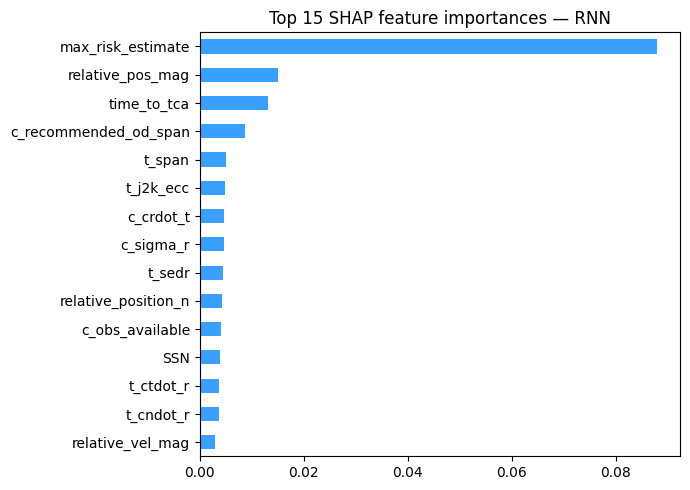

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
importance.head(15).sort_values().plot(kind="barh", ax=ax, color="#3aa0ff")
ax.set_title(f"Top 15 SHAP feature importances — {best_name}")
plt.tight_layout()
plt.show()

## 8. Decision Engine — sample predictions on the winning model

In [11]:
sys.path.insert(0, str(PROJECT_ROOT / "src" / "scripts"))
from decision_engine import decide

for idx in [0, 1, 2]:
    row = df[feature_cols].iloc[idx].values.astype("float32").reshape(1, 1, n_features)
    prob = float(best_model.predict(row, verbose=0)[0][0])
    decision = decide(prob)
    print(f"Row {idx}: P(collision)={prob:.4f}  ->  risk_level={decision.risk_level}  action='{decision.action}'")

Row 0: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'
Row 1: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'
Row 2: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'


## Summary

| Step | Result |
|---|---|
| Dataset | `data/engineered_data.csv` — real ESA conjunction events, 102 features |
| Best model | See §5 above (auto-selected by combined F1 + ROC-AUC) |
| Deployment artifacts | `models/best_model.keras`, `models/best_model.h5`, `models/deployment_npy/<winner>/`, `models/scaler.joblib` |
| Explainability | SHAP KernelExplainer, top features in §7 |
| Decision Engine | `src/scripts/decision_engine.py::decide()` — same logic used by the FastAPI backend and Streamlit dashboard |

This notebook, `src/scripts/train_models.py`, `src/backend/app.py`, and
`src/frontend/mission_control.py` all agree on the same model contract:
`(batch, 1, 102) -> P(collision)`. No logic is duplicated — the notebook
imports the production training functions directly.